# 03. Model Fuzzy Sugeno

Setelah menyelesaikan notebook ini, mahasiswa diharapkan mampu membedakan Mamdani dan Sugeno, menghitung keluaran Sugeno orde nol dan orde satu, membangun model dengan beberapa input, serta memeriksa kondisi batas dan interpretasi hasilnya.

## Setup

Jalankan sel ini lebih dahulu. Fungsi keanggotaan tetap diambil dari `membership.py` agar definisinya sama dengan Notebook 01 dan 02.

In [1]:
# Standard setup cell - run before other cells.
import importlib.util
import subprocess
import sys
from pathlib import Path

def ensure_dependencies():
    """Install only packages used by this module."""
    required = {"numpy": "numpy", "matplotlib": "matplotlib", "pandas": "pandas"}
    missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_module_dir(start):
    """Find the shared membership module."""
    for root in [start, *start.parents]:
        for candidate in (root, root / "Fuzzy Logic"):
            if (candidate / "membership.py").exists():
                return candidate
        if (root / ".git").exists():
            break
    return None

ensure_dependencies()
module_dir = find_module_dir(Path.cwd())
if module_dir is None and "google.colab" in sys.modules:
    clone_dir = Path("Modul-Praktikum-KK-RKA-25")
    if not clone_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/kcv-if/Modul-Praktikum-KK-RKA-25.git", str(clone_dir)], check=True)
    module_dir = find_module_dir(clone_dir)
if module_dir is None:
    raise RuntimeError("membership.py not found; open this notebook inside the repository")
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from membership import linear_up, linear_down, triangular, trapezoidal

print("Python:", sys.version.split()[0])
print("Membership module:", module_dir / "membership.py")

Python: 3.13.12
Membership module: /home/ata/school/Modul-Praktikum-KK-RKA-25/Fuzzy Logic/membership.py


## 3.1 Overview Fuzzy Logic: Sugeno

Pada model **Mamdani**, konsekuen aturan berbentuk himpunan fuzzy, misalnya *kecepatan Rendah*. Kurva keluaran setiap aturan perlu dikenai implikasi, diagregasikan, lalu didefuzzifikasi.

Pada model **Sugeno**, konsekuen setiap aturan langsung berupa nilai numerik atau fungsi dari input. Contohnya:

$$R_1:\quad \text{IF jarak Dekat THEN } z_1=5.$$

Jika konsekuennya konstanta, model disebut **Sugeno orde nol**. Jika konsekuennya fungsi linier dari input, model disebut **Sugeno orde satu**. Untuk input $x_1,\ldots,x_n$:

$$\text{orde nol: } f_i=c_i,$$

$$\text{orde satu: } f_i(x_1,\ldots,x_n)=p_{i1}x_1+\cdots+p_{in}x_n+r_i.$$

Kekuatan aktivasi aturan tetap dihitung dari anteseden fuzzy. Jika kekuatan aturan ke-$i$ adalah $w_i$ dan nilai konsekuennya adalah $z_i=f_i(\mathbf{x})$, keluaran akhirnya dihitung dengan **rata-rata berbobot**:

$$z^*=\frac{\sum_{i=1}^{m}w_i z_i}{\sum_{i=1}^{m}w_i},\qquad \sum_i w_i>0.$$

Normalisasi bobot $\bar{w}_i=w_i/\sum_j w_j$ memberikan bentuk ekuivalen $z^*=\sum_i\bar{w}_i z_i$.

| Aspek | Mamdani | Sugeno |
|---|---|---|
| Konsekuen aturan | Himpunan fuzzy | Konstanta atau fungsi input |
| Hasil tiap aturan | Kurva fuzzy | Satu nilai numerik $z_i$ |
| Penggabungan akhir | Agregasi kurva | Rata-rata berbobot |
| Langkah akhir | Defuzzifikasi, misalnya centroid | Perhitungan langsung dari bobot |
| Kebutuhan domain output diskret | Umumnya diperlukan | Tidak diperlukan untuk inferensi |

Alur Sugeno yang dipakai pada notebook ini adalah:

$$\boxed{\text{input crisp}\rightarrow\text{fuzzifikasi}\rightarrow\text{evaluasi anteseden}\rightarrow\text{evaluasi fungsi konsekuen}\rightarrow\text{rata-rata berbobot}\rightarrow\text{output crisp}}$$

Operator anteseden yang digunakan adalah AND = min, OR = max, dan NOT = $1-\mu$. Pilihan operator harus dinyatakan karena operator lain juga dapat digunakan dalam rancangan Sugeno.

---
## 3.2 Langkah 1: fuzzifikasi input

Agar dapat dibandingkan langsung dengan Notebook 02, gunakan kembali variabel **Jarak** dengan domain $[0,10]$ meter dan tiga label berikut:

| Label | Fungsi keanggotaan |
|---|---|
| Dekat | `linear_down(x, 2, 4)` |
| Sedang | `trapezoidal(x, 1, 4, 6, 9)` |
| Jauh | `linear_up(x, 6, 8)` |

Untuk $x=3{,}5$ m, hasil fuzzifikasi adalah $[0{,}25;\ 5/6;\ 0]$ dalam urutan dekat, sedang, dan jauh. Tahap ini sama untuk Mamdani maupun Sugeno karena perbedaannya terletak pada bentuk konsekuen dan cara menghasilkan output akhir.

### Contoh penerapan

dekat     0.250000
sedang    0.833333
jauh      0.000000
Name: derajat pada 3,5 m, dtype: float64

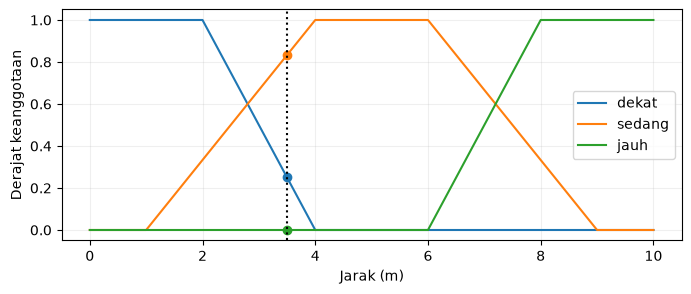

In [2]:
def fuzzify_distance(distance):
    """Hitung derajat jarak pada domain praktikum 0 sampai 10 meter."""
    if not np.isfinite(distance) or not 0 <= distance <= 10:
        raise ValueError("Jarak harus berada pada domain 0-10 meter.")
    return {
        "dekat": linear_down(distance, 2, 4),
        "sedang": trapezoidal(distance, 1, 4, 6, 9),
        "jauh": linear_up(distance, 6, 8),
    }

distance = 3.5
input_degrees = fuzzify_distance(distance)
display(pd.Series(input_degrees, name="derajat pada 3,5 m"))

distance_grid = np.linspace(0, 10, 501)
plt.figure(figsize=(8, 3))
for label in input_degrees:
    curve = [fuzzify_distance(x)[label] for x in distance_grid]
    plt.plot(distance_grid, curve, label=label)
    plt.scatter([distance], [input_degrees[label]])
plt.axvline(distance, color="black", linestyle=":")
plt.xlabel("Jarak (m)")
plt.ylabel("Derajat keanggotaan")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Dua aturan akan aktif karena label dekat dan sedang memiliki derajat bukan nol. Seperti pada Notebook 02, jumlah derajat tidak harus sama dengan 1; normalisasi dilakukan pada **bobot aturan** saat menghitung keluaran Sugeno.

---
## 3.3 Langkah 2: evaluasi aturan Sugeno orde nol

Tetapkan konsekuen konstan yang mewakili kecepatan rendah, sedang, dan tinggi:

| Aturan | Anteseden | Konsekuen Sugeno |
|---|---|---:|
| R1 | IF jarak Dekat | THEN $z_1=5$ m/s |
| R2 | IF jarak Sedang | THEN $z_2=15$ m/s |
| R3 | IF jarak Jauh | THEN $z_3=25$ m/s |

Karena setiap aturan hanya mempunyai satu kondisi, $w_i$ langsung sama dengan derajat label pada antesedennya. Nilai $z_i$ bukan derajat keanggotaan: satuannya adalah m/s dan nilainya tidak dibatasi pada $[0,1]$.

### Contoh penerapan

In [3]:
zero_order_rules = [
    {"aturan": "R1", "input": "dekat", "konsekuen": 5.0},
    {"aturan": "R2", "input": "sedang", "konsekuen": 15.0},
    {"aturan": "R3", "input": "jauh", "konsekuen": 25.0},
]

rule_rows = []
for rule in zero_order_rules:
    weight = input_degrees[rule["input"]]
    rule_rows.append({
        "aturan": rule["aturan"],
        "label input": rule["input"],
        "w_i": weight,
        "z_i (m/s)": rule["konsekuen"],
        "w_i z_i": weight * rule["konsekuen"],
    })
rule_table = pd.DataFrame(rule_rows)
display(rule_table.round(4))

,aturan,label input,w_i,z_i (m/s),w_i z_i
0,R1,dekat,0.2500,5.0,1.25
1,R2,sedang,0.8333,15.0,12.50
2,R3,jauh,0.0000,25.0,0.00


R1 menyumbang $0{,}25	imes5=1{,}25$ dan R2 menyumbang $(5/6)	imes15=12{,}5$ pada pembilang. R3 tidak menyumbang karena bobotnya nol. Aturan dengan bobot nol boleh tetap ditampilkan agar proses dapat diaudit.

---
## 3.4 Langkah 3: menghitung rata-rata berbobot

Untuk contoh ini:

$$z^*=\frac{0{,}25(5)+(5/6)(15)+0(25)}{0{,}25+5/6+0}\approx12{,}69\text{ m/s}.$$

Pembagian dengan jumlah bobot membuat pengaruh aturan bersifat relatif. Bobot ternormalisasi berjumlah 1 dan menunjukkan proporsi kontribusi tiap aturan. Jika semua bobot nol, rumus tidak terdefinisi; model harus memperbaiki cakupan fungsi keanggotaan atau menyediakan aturan yang sesuai, bukan diam-diam mengembalikan nol.

### Contoh penerapan

,aturan,w_i,bobot normal,z_i (m/s),kontribusi akhir
0,R1,0.2500,0.2308,5.0,1.1538
1,R2,0.8333,0.7692,15.0,11.5385
2,R3,0.0000,0.0000,25.0,0.0000


Output Sugeno orde nol: 12.69 m/s


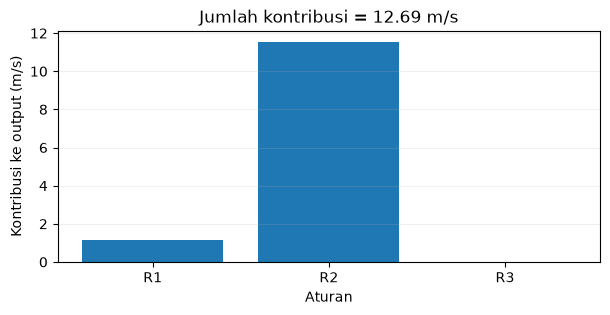

In [4]:
def weighted_average(weights, consequences):
    """Hitung output Sugeno dari bobot nonnegatif dan konsekuen numerik."""
    weights = np.asarray(weights, dtype=float)
    consequences = np.asarray(consequences, dtype=float)
    if weights.shape != consequences.shape or weights.ndim != 1:
        raise ValueError("Bobot dan konsekuen harus berupa vektor dengan bentuk yang sama.")
    if not np.all(np.isfinite(weights)) or not np.all(np.isfinite(consequences)):
        raise ValueError("Bobot dan konsekuen harus bernilai hingga.")
    if np.any(weights < 0):
        raise ValueError("Bobot aturan tidak boleh negatif.")
    total_weight = float(weights.sum())
    if total_weight <= 0:
        raise ValueError("Tidak ada aturan aktif; periksa cakupan anteseden.")
    return float(np.dot(weights, consequences) / total_weight)

weights = rule_table["w_i"].to_numpy()
consequences = rule_table["z_i (m/s)"].to_numpy()
normalized_weights = weights / weights.sum()
crisp_speed_zero = weighted_average(weights, consequences)

display(pd.DataFrame({
    "aturan": rule_table["aturan"],
    "w_i": weights,
    "bobot normal": normalized_weights,
    "z_i (m/s)": consequences,
    "kontribusi akhir": normalized_weights * consequences,
}).round(4))
print(f"Output Sugeno orde nol: {crisp_speed_zero:.2f} m/s")

plt.figure(figsize=(7, 3))
plt.bar(rule_table["aturan"], normalized_weights * consequences, color="tab:blue")
plt.ylabel("Kontribusi ke output (m/s)")
plt.xlabel("Aturan")
plt.title(f"Jumlah kontribusi = {crisp_speed_zero:.2f} m/s")
plt.grid(axis="y", alpha=0.2)
plt.show()

Bobot normal R1 sekitar 0,2308 dan R2 sekitar 0,7692. Output 12,69 m/s berada di antara konsekuen aktif 5 dan 15 m/s. Sifat ini selalu berlaku untuk rata-rata berbobot dengan bobot nonnegatif: output tidak dapat lebih kecil dari konsekuen aktif minimum atau lebih besar dari konsekuen aktif maksimum.

---
## 3.5 Aplikasi utuh Sugeno orde nol

Gabungkan fuzzifikasi, evaluasi aturan, dan rata-rata berbobot ke satu fungsi. Karena fungsi ini mengembalikan hasil antara, pengguna dapat memeriksa alasan di balik output akhir.

Konsekuen konstan tidak otomatis membuat keluaran sistem berbentuk tangga. Di daerah tumpang tindih, perubahan bobot menginterpolasi beberapa konstanta sehingga keluaran dapat berubah secara halus. Bentuk kurva tetap bergantung pada fungsi keanggotaan dan cakupan aturan.

### Contoh penerapan

,jarak (m),dekat,sedang,jauh,kecepatan (m/s)
0,0.0,1.00,0.0000,0.00,5.0000
1,2.5,0.75,0.5000,0.00,9.0000
2,3.5,0.25,0.8333,0.00,12.6923
3,5.0,0.00,1.0000,0.00,15.0000
4,7.5,0.00,0.5000,0.75,21.0000
5,10.0,0.00,0.0000,1.00,25.0000


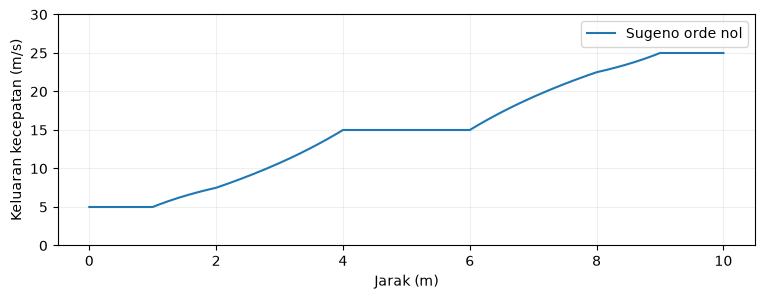

In [5]:
def sugeno_zero_speed(distance):
    degrees = fuzzify_distance(distance)
    rule_weights = np.array([degrees[rule["input"]] for rule in zero_order_rules])
    rule_outputs = np.array([rule["konsekuen"] for rule in zero_order_rules])
    return {
        "input_degrees": degrees,
        "weights": rule_weights,
        "consequences": rule_outputs,
        "speed": weighted_average(rule_weights, rule_outputs),
    }

rows = []
for x in [0, 2.5, 3.5, 5, 7.5, 10]:
    result = sugeno_zero_speed(x)
    rows.append({"jarak (m)": x, **result["input_degrees"], "kecepatan (m/s)": result["speed"]})
display(pd.DataFrame(rows).round(4))

trial_distances = np.linspace(0, 10, 201)
zero_speeds = [sugeno_zero_speed(x)["speed"] for x in trial_distances]
plt.figure(figsize=(9, 3))
plt.plot(trial_distances, zero_speeds, label="Sugeno orde nol")
plt.xlabel("Jarak (m)")
plt.ylabel("Keluaran kecepatan (m/s)")
plt.ylim(0, 30)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Pada 0, 5, dan 10 m hanya satu aturan dominan sehingga keluarannya tepat 5, 15, dan 25 m/s. Pada daerah tumpang tindih, output merupakan campuran konsekuen aturan aktif. Tidak diperlukan grid kecepatan, kurva output fuzzy, implikasi min, agregasi max, maupun integral centroid.

---
## 3.6 Sugeno orde satu

Pada Sugeno orde satu, nilai konsekuen berubah mengikuti input. Untuk contoh satu input, gunakan:

| Aturan | Konsekuen linier |
|---|---|
| R1: jarak Dekat | $z_1=2+1{,}2x$ |
| R2: jarak Sedang | $z_2=7+1{,}6x$ |
| R3: jarak Jauh | $z_3=12+1{,}8x$ |

Pada $x=3{,}5$ m, nilai konsekuen lokalnya adalah 6,2; 12,6; dan 18,3 m/s. Walaupun R3 menghasilkan angka, nilainya tidak berpengaruh karena bobot R3 nol. Koefisien pada tabel merupakan parameter model yang harus ditetapkan dari pengetahuan pakar atau dipelajari dari data; angka tersebut bukan hasil fuzzifikasi.

### Contoh penerapan

,aturan,rumus konsekuen,w_i,z_i (m/s),w_i z_i
0,R1,"2 + 1,2x",0.2500,6.2,1.55
1,R2,"7 + 1,6x",0.8333,12.6,10.50
2,R3,"12 + 1,8x",0.0000,18.3,0.00


Output Sugeno orde satu: 11.12 m/s


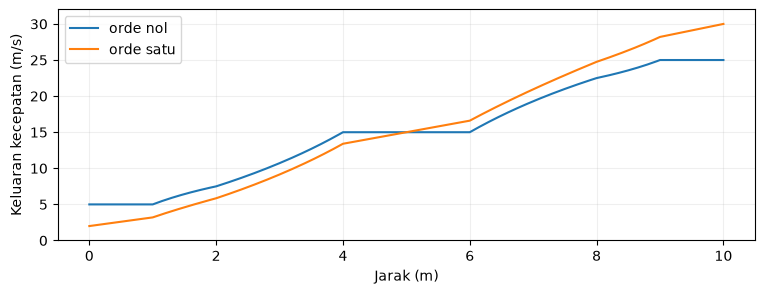

In [6]:
first_order_rules = [
    {"aturan": "R1", "input": "dekat", "fungsi": lambda x: 2 + 1.2 * x, "rumus": "2 + 1,2x"},
    {"aturan": "R2", "input": "sedang", "fungsi": lambda x: 7 + 1.6 * x, "rumus": "7 + 1,6x"},
    {"aturan": "R3", "input": "jauh", "fungsi": lambda x: 12 + 1.8 * x, "rumus": "12 + 1,8x"},
]

def sugeno_first_speed(distance):
    degrees = fuzzify_distance(distance)
    rule_weights = np.array([degrees[rule["input"]] for rule in first_order_rules])
    rule_outputs = np.array([rule["fungsi"](distance) for rule in first_order_rules])
    return {
        "input_degrees": degrees,
        "weights": rule_weights,
        "consequences": rule_outputs,
        "speed": weighted_average(rule_weights, rule_outputs),
    }

first_result = sugeno_first_speed(distance)
display(pd.DataFrame({
    "aturan": [rule["aturan"] for rule in first_order_rules],
    "rumus konsekuen": [rule["rumus"] for rule in first_order_rules],
    "w_i": first_result["weights"],
    "z_i (m/s)": first_result["consequences"],
    "w_i z_i": first_result["weights"] * first_result["consequences"],
}).round(4))
print(f"Output Sugeno orde satu: {first_result['speed']:.2f} m/s")

first_speeds = [sugeno_first_speed(x)["speed"] for x in trial_distances]
plt.figure(figsize=(9, 3))
plt.plot(trial_distances, zero_speeds, label="orde nol")
plt.plot(trial_distances, first_speeds, label="orde satu")
plt.xlabel("Jarak (m)")
plt.ylabel("Keluaran kecepatan (m/s)")
plt.ylim(0, 32)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Untuk 3,5 m, keluaran orde satu sekitar **11,12 m/s**. Hasilnya berbeda dari orde nol karena tiap aturan sekarang mempunyai model lokal yang berubah terhadap jarak. Garis konsekuen tidak perlu saling bertemu, tetapi pemilihan koefisien yang buruk dapat menimbulkan perubahan tajam atau output yang tidak masuk akal; karena itu perilaku model perlu diperiksa pada seluruh domain.

---
## 3.7 Sugeno orde satu dengan dua input

Contoh berikut menentukan persentase kecepatan kipas dari suhu $T$ dan kelembapan $H$. Fuzzifikasi dilakukan terpisah untuk setiap variabel, kemudian setiap pasangan label dihubungkan dengan AND = min.

**Suhu** pada domain $[15,40]$ °C: Sejuk = `linear_down(T, 20, 28)`, Nyaman = `triangular(T, 20, 28, 36)`, dan Panas = `linear_up(T, 28, 36)`.

**Kelembapan** pada domain $[20,90]$ persen: Kering = `linear_down(H, 35, 55)`, Normal = `trapezoidal(H, 35, 45, 60, 75)`, dan Lembap = `linear_up(H, 60, 80)`.

Kesembilan aturan memakai bentuk konsekuen $z_i=b_i+0{,}8(T-15)+0{,}15(H-20)$. Nilai dasar $b_i$ adalah:

| Suhu / Kelembapan | Kering | Normal | Lembap |
|---|---:|---:|---:|
| Sejuk | 5 | 10 | 15 |
| Nyaman | 25 | 30 | 35 |
| Panas | 55 | 60 | 65 |

Bentuk terpusat $(T-15)$ dan $(H-20)$ memudahkan interpretasi intersep, tetapi secara aljabar tetap merupakan fungsi linier. Parameter ini hanya rancangan simulasi, bukan spesifikasi keselamatan perangkat nyata.

### Contoh penerapan

,suhu,kelembapan
sejuk,0.0,-
nyaman,0.75,-
panas,0.25,-
kering,-,0.0
normal,-,0.333333
lembap,-,0.5


,aturan,w_i,z_i,w_i z_i
0,sejuk AND kering,0.0000,24.5,0.000
1,sejuk AND normal,0.0000,29.5,0.000
2,sejuk AND lembap,0.0000,34.5,0.000
3,nyaman AND kering,0.0000,44.5,0.000
4,nyaman AND normal,0.3333,49.5,16.500
5,nyaman AND lembap,0.5000,54.5,27.250
6,panas AND kering,0.0000,74.5,0.000
7,panas AND normal,0.2500,79.5,19.875
8,panas AND lembap,0.2500,84.5,21.125


Rekomendasi kecepatan kipas: 63.56%


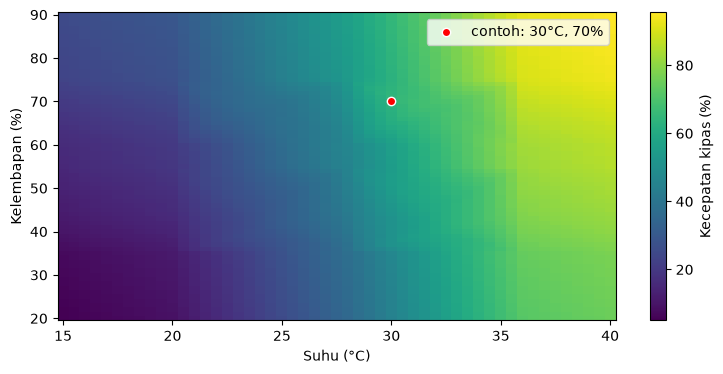

In [7]:
def fuzzify_fan_inputs(temperature, humidity):
    if not np.isfinite(temperature) or not 15 <= temperature <= 40:
        raise ValueError("Suhu harus berada pada domain 15-40 °C.")
    if not np.isfinite(humidity) or not 20 <= humidity <= 90:
        raise ValueError("Kelembapan harus berada pada domain 20-90 persen.")
    temperature_degrees = {
        "sejuk": linear_down(temperature, 20, 28),
        "nyaman": triangular(temperature, 20, 28, 36),
        "panas": linear_up(temperature, 28, 36),
    }
    humidity_degrees = {
        "kering": linear_down(humidity, 35, 55),
        "normal": trapezoidal(humidity, 35, 45, 60, 75),
        "lembap": linear_up(humidity, 60, 80),
    }
    return temperature_degrees, humidity_degrees

fan_bases = {
    ("sejuk", "kering"): 5, ("sejuk", "normal"): 10, ("sejuk", "lembap"): 15,
    ("nyaman", "kering"): 25, ("nyaman", "normal"): 30, ("nyaman", "lembap"): 35,
    ("panas", "kering"): 55, ("panas", "normal"): 60, ("panas", "lembap"): 65,
}

def sugeno_fan(temperature, humidity):
    temperature_degrees, humidity_degrees = fuzzify_fan_inputs(temperature, humidity)
    records = []
    for (temperature_label, humidity_label), base in fan_bases.items():
        weight = min(temperature_degrees[temperature_label], humidity_degrees[humidity_label])
        consequence = base + 0.8 * (temperature - 15) + 0.15 * (humidity - 20)
        records.append({
            "aturan": f"{temperature_label} AND {humidity_label}",
            "w_i": weight,
            "z_i": consequence,
            "w_i z_i": weight * consequence,
        })
    table = pd.DataFrame(records)
    output = weighted_average(table["w_i"], table["z_i"])
    return output, table, temperature_degrees, humidity_degrees

fan_output, fan_table, temperature_degrees, humidity_degrees = sugeno_fan(30, 70)
display(pd.DataFrame({"suhu": temperature_degrees, "kelembapan": humidity_degrees}).fillna("-"))
display(fan_table.round(4))
print(f"Rekomendasi kecepatan kipas: {fan_output:.2f}%")

temperature_grid = np.linspace(15, 40, 51)
humidity_grid = np.linspace(20, 90, 71)
fan_surface = np.array([
    [sugeno_fan(t, h)[0] for t in temperature_grid]
    for h in humidity_grid
])
plt.figure(figsize=(9, 4))
mesh = plt.pcolormesh(temperature_grid, humidity_grid, fan_surface, shading="auto", cmap="viridis")
plt.scatter([30], [70], color="red", edgecolor="white", label="contoh: 30°C, 70%")
plt.xlabel("Suhu (°C)")
plt.ylabel("Kelembapan (%)")
plt.colorbar(mesh, label="Kecepatan kipas (%)")
plt.legend()
plt.show()

Pada 30°C dan kelembapan 70%, beberapa aturan aktif bersamaan dan menghasilkan keluaran sekitar **63,56%**. Peta warna memperlihatkan respons model pada seluruh domain. Pemeriksaan global seperti ini penting: satu contoh numerik belum cukup untuk memastikan arah perubahan, kehalusan transisi, dan rentang output sesuai tujuan rancangan.

---
## 3.8 Validasi dan perbandingan dengan Mamdani

Beberapa pemeriksaan dasar untuk model Sugeno adalah:

1. seluruh input berada pada domain yang didefinisikan;
2. bobot aturan bernilai hingga dan tidak negatif;
3. sedikitnya satu aturan aktif untuk setiap input yang diizinkan;
4. output berada di antara nilai konsekuen aturan aktif;
5. satuan setiap fungsi konsekuen sesuai dengan satuan output; dan
6. respons pada seluruh domain sesuai dengan maksud basis aturan.

Untuk input jarak 3,5 m, model Mamdani pada Notebook 02 menghasilkan sekitar 13,36 m/s, sedangkan Sugeno orde nol pada notebook ini menghasilkan sekitar 12,69 m/s. Perbedaan tersebut wajar: Mamdani menghitung centroid dari bentuk kurva keluaran teragregasi, sedangkan Sugeno merata-ratakan nilai konsekuen. Kesamaan label aturan tidak menjadikan kedua model ekuivalen.

### Contoh penerapan

In [8]:
# Pemeriksaan numerik sederhana. Assertion akan berhenti jika sifat yang diuji tidak terpenuhi.
active = weights > 0
assert np.isclose(normalized_weights.sum(), 1.0)
assert consequences[active].min() <= crisp_speed_zero <= consequences[active].max()
assert np.isclose(weighted_average(10 * weights, consequences), crisp_speed_zero)

comparison = pd.DataFrame({
    "metode": ["Mamdani max-min + centroid", "Sugeno orde nol", "Sugeno orde satu"],
    "output pada 3,5 m (m/s)": [13.36, crisp_speed_zero, first_result["speed"]],
    "bentuk konsekuen": ["himpunan fuzzy", "konstanta", "fungsi linier"],
})
display(comparison.round(2))

try:
    weighted_average([0, 0], [5, 15])
except ValueError as error:
    print("Kasus tanpa aturan aktif ditolak:", error)

,metode,"output pada 3,5 m (m/s)",bentuk konsekuen
0,Mamdani max-min + centroid,13.36,himpunan fuzzy
1,Sugeno orde nol,12.69,konstanta
2,Sugeno orde satu,11.12,fungsi linier


Kasus tanpa aturan aktif ditolak: Tidak ada aturan aktif; periksa cakupan anteseden.


Mengalikan semua bobot dengan faktor positif yang sama tidak mengubah output karena faktor tersebut habis pada pembilang dan penyebut. Sebaliknya, mengubah bobot satu aturan saja akan mengubah proporsi kontribusinya. Pilihan Mamdani atau Sugeno sebaiknya didasarkan pada kebutuhan interpretasi, kemudahan komputasi, ketersediaan model lokal, dan hasil validasi—bukan pada anggapan bahwa salah satunya selalu lebih akurat.

---
## Latihan Soal

Selesaikan tiga kasus berikut dengan **metode Sugeno**. Tulis perhitungan manual sebelum memeriksanya dengan Python. Gunakan AND = min, OR = max, dan NOT = $1-\mu$ bila operator tersebut muncul.

Untuk setiap kasus:

1. hitung derajat keanggotaan setiap input;
2. tuliskan kekuatan aktivasi seluruh aturan, termasuk yang bernilai nol;
3. evaluasi nilai konsekuen setiap aturan;
4. hitung $\sum w_i$, $\sum w_i z_i$, dan output rata-rata berbobot;
5. periksa bahwa output berada di antara konsekuen aturan aktif; dan
6. jelaskan perubahan output ketika input pembanding diberikan.

Gunakan fungsi dari `membership.py` dan fungsi `weighted_average` yang telah tersedia. Tulis jawaban pada sel kosong; tambahkan sel Markdown atau kode jika diperlukan.

### Soal 1 - Pengaturan kecepatan kipas, Sugeno orde nol

Sebuah pengendali menentukan persentase kecepatan kipas dari suhu ruangan. Hitung output untuk **28°C**, lalu ulangi untuk **36°C**.

**Input suhu** $T\in[10,45]$ °C:

| Label | Fungsi keanggotaan |
|---|---|
| Sejuk | `linear_down(T, 20, 30)` |
| Nyaman | `triangular(T, 20, 30, 40)` |
| Panas | `linear_up(T, 30, 40)` |

**Aturan Sugeno orde nol:**

| Aturan | Anteseden | Konsekuen |
|---|---|---:|
| R1 | IF suhu Sejuk | THEN $z_1=20\%$ |
| R2 | IF suhu Nyaman | THEN $z_2=50\%$ |
| R3 | IF suhu Panas | THEN $z_3=90\%$ |

Bandingkan aturan aktif dan rekomendasi kedua suhu. Jelaskan mengapa tidak diperlukan kurva fungsi keanggotaan output.

In [ ]:
# Soal 1 - kipas Sugeno orde nol
# Perhitungan manual saya (ditulis dulu, baru dicek pakai python):
# T=28: sejuk=(30-28)/10=0.2, nyaman=(28-20)/(30-20)=0.8, panas=0 (karena 28<30)
#   w=[0.2, 0.8, 0], sum w=1.0, sum wz=0.2*20+0.8*50=4+40=44 -> z*=44%
# T=36: sejuk=0, nyaman=(40-36)/(40-30)=0.4, panas=(36-30)/10=0.6
#   sum w=1.0, sum wz=0.4*50+0.6*90=20+54=74 -> z*=74%

def fuzzify_suhu(T):
    # domain soal 10-45, kalau di luar berarti input tidak valid
    if not 10 <= T <= 45:
        raise ValueError("Suhu harus 10-45 C")
    return {
        "sejuk": linear_down(T, 20, 30),
        "nyaman": triangular(T, 20, 30, 40),
        "panas": linear_up(T, 30, 40),
    }

konsekuen = {"sejuk": 20.0, "nyaman": 50.0, "panas": 90.0}  # R1, R2, R3

for T in [28, 36]:
    print(f"\n=== Suhu {T} C ===")
    # 1. derajat keanggotaan
    d = fuzzify_suhu(T)
    print(f"derajat: sejuk={d['sejuk']:.4f}, nyaman={d['nyaman']:.4f}, panas={d['panas']:.4f}")
    # 2. kekuatan aktivasi (satu kondisi jadi w = derajatnya langsung)
    w = [d["sejuk"], d["nyaman"], d["panas"]]
    print(f"bobot w: R1={w[0]:.4f}, R2={w[1]:.4f}, R3={w[2]:.4f} (nol tetap ditulis biar bisa diaudit)")
    # 3. nilai konsekuen
    z = [konsekuen["sejuk"], konsekuen["nyaman"], konsekuen["panas"]]
    print(f"konsekuen z: {z} (%)")
    # 4. rata-rata berbobot
    sum_w = sum(w)
    sum_wz = sum(wi*zi for wi, zi in zip(w, z))
    out = weighted_average(w, z)
    print(f"sum w={sum_w:.4f}, sum wz={sum_wz:.4f}, output={sum_wz:.4f}/{sum_w:.4f}={out:.2f}%")
    # 5. cek output di antara konsekuen aktif
    aktif = [zi for wi, zi in zip(w, z) if wi > 0]
    print(f"cek: min aktif={min(aktif)}, max aktif={max(aktif)} -> {'OK' if min(aktif) <= out <= max(aktif) else 'GAGAL'}")

# tabel ringkasan biar rapi
rows = []
for T in [28, 36]:
    d = fuzzify_suhu(T)
    w = [d["sejuk"], d["nyaman"], d["panas"]]
    z = [20.0, 50.0, 90.0]
    rows.append({"suhu (C)": T, "sejuk": w[0], "nyaman": w[1], "panas": w[2],
                 "sum w": sum(w), "sum wz": sum(a*b for a, b in zip(w, z)),
                 "output (%)": weighted_average(w, z)})
display(pd.DataFrame(rows).round(4))

# 6. perbandingan + kenapa tidak perlu kurva output
print("\nKesimpulan: T=28 -> 44% (didominasi R2 nyaman), T=36 -> 74% (campuran R2+R3).")
print("Aturan aktif beda: 28C (R1+R2), 36C (R2+R3), jadi output naik 30%.")
print("Tidak perlu kurva MF output karena konsekuen Sugeno sudah angka (20/50/90%),")
print("jadi tidak ada implikasi min, agregasi max, dan centroid seperti Mamdani.")

plt.figure(figsize=(6, 3))
plt.bar(["28C", "36C"], [44, 74], color=["tab:blue", "tab:orange"])
plt.ylabel("Output kipas (%)")
plt.title("Perbandingan output soal 1")
plt.grid(axis="y", alpha=0.2)
plt.show()


<details>
<summary>Klik untuk melihat hint</summary>

Karena setiap aturan hanya memiliki satu kondisi, bobotnya langsung sama dengan derajat Sejuk, Nyaman, atau Panas. Bentuk dua vektor: bobot aturan dan konstanta konsekuen, lalu gunakan `weighted_average`.

</details>

### Soal 2 - Durasi pencucian dengan dua input

Sebuah mesin cuci menentukan durasi dari indeks kekotoran **65** dan berat pakaian **6,5 kg**. Setelah itu, ulangi untuk indeks kekotoran **35** dengan berat tetap 6,5 kg.

**Kekotoran** $k\in[0,100]$: Rendah = `linear_down(k, 20, 50)`, Sedang = `trapezoidal(k, 20, 40, 60, 80)`, dan Tinggi = `linear_up(k, 50, 80)`.

**Berat** $b\in[0,10]$ kg: Ringan = `linear_down(b, 2, 5)`, Sedang = `triangular(b, 2, 5, 8)`, dan Berat = `linear_up(b, 5, 8)`.

Setiap sel adalah konsekuen konstan dalam menit. Baris menyatakan kekotoran, kolom menyatakan berat, dan anteseden memakai AND = min.

| Kekotoran / Berat | Ringan | Sedang | Berat |
|---|---:|---:|---:|
| Rendah | 15 | 20 | 30 |
| Sedang | 20 | 35 | 50 |
| Tinggi | 30 | 50 | 60 |

Beri nama R1–R9 dari kiri ke kanan pada setiap baris. Sajikan semua bobot dan jelaskan aturan yang paling memengaruhi perubahan durasi.

In [ ]:
# Soal 2 - mesin cuci, 2 input, Sugeno orde nol
# Perhitungan manual saya:
# Berat b=6.5 tetap: ringan=(5-6.5)/3 -> 0, sedang=(8-6.5)/3=0.5, berat=(6.5-5)/3=0.5
# k=65: rendah=0, sedang=(80-65)/20=0.75, tinggi=(65-50)/30=0.5
# k=35: rendah=(50-35)/30=0.5, sedang=(35-20)/20=0.75, tinggi=0
# Bobot = min(baris, kolom). R1-R9 urut kiri-kanan per baris.

def fuzzify_kotor(k):
    return {"rendah": linear_down(k, 20, 50),
            "sedang": trapezoidal(k, 20, 40, 60, 80),
            "tinggi": linear_up(k, 50, 80)}

def fuzzify_berat(b):
    return {"ringan": linear_down(b, 2, 5),
            "sedang": triangular(b, 2, 5, 8),
            "berat": linear_up(b, 5, 8)}

# tabel konsekuen (baris=kotor, kolom=berat)
basis = {(("rendah","ringan"),15),(("rendah","sedang"),20),(("rendah","berat"),30),
         (("sedang","ringan"),20),(("sedang","sedang"),35),(("sedang","berat"),50),
         (("tinggi","ringan"),30),(("tinggi","sedang"),50),(("tinggi","berat"),60)}
aturan = [(f"R{i+1} {(r+' & '+c)}", r, c, z) for i, ((r,c),z) in enumerate(
    [(("rendah","ringan"),15),(("rendah","sedang"),20),(("rendah","berat"),30),
     (("sedang","ringan"),20),(("sedang","sedang"),35),(("sedang","berat"),50),
     (("tinggi","ringan"),30),(("tinggi","sedang"),50),(("tinggi","berat"),60)])]

def hitung_mesin_cuci(k, b):
    dk, db = fuzzify_kotor(k), fuzzify_berat(b)
    recs = []
    for nama, r, c, z in aturan:
        w = min(dk[r], db[c])  # AND = min
        recs.append({"aturan": nama, "w": w, "z": z, "wz": w*z})
    tabel = pd.DataFrame(recs)
    out = weighted_average(tabel["w"], tabel["z"])
    return dk, db, tabel, out

for k, b in [(65, 6.5), (35, 6.5)]:
    print(f"\n=== kotor={k}, berat={b} kg ===")
    dk, db, tabel, out = hitung_mesin_cuci(k, b)
    print(f"kotor: rendah={dk['rendah']:.4f}, sedang={dk['sedang']:.4f}, tinggi={dk['tinggi']:.4f}")
    print(f"berat: ringan={db['ringan']:.4f}, sedang={db['sedang']:.4f}, berat={db['berat']:.4f}")
    display(tabel.round(4))
    print(f"sum w={tabel['w'].sum():.4f}, sum wz={tabel['wz'].sum():.4f}, output={out:.2f} menit")
    aktif = tabel[tabel["w"] > 0]["z"]
    print(f"cek: output {out:.2f} di antara [{aktif.min()}, {aktif.max()}] -> {'OK' if aktif.min() <= out <= aktif.max() else 'GAGAL'}")

print("\nKesimpulan:")
print("- k=65 -> 48.75 mnt (aktif R5,R6,R8,R9 @0.5). k=35 -> 33.75 mnt (aktif R2,R3,R5,R6 @0.5).")
print("- Durasi turun 15 menit saat kotor berkurang, karena R8/R9 (50/60 mnt) mati")
print("  dan diganti R2/R3 (20/30 mnt). Yang paling ngaruh ya R8,R9 vs R2,R3,")
print("  sedangkan R5,R6 tetap aktif 0.5 di kedua kasus jadi tidak mengubah selisih.")

# plot biar kelihatan kontribusi tiap aturan
_, _, t1, o1 = hitung_mesin_cuci(65, 6.5)
_, _, t2, o2 = hitung_mesin_cuci(35, 6.5)
x = range(1, 10)
plt.figure(figsize=(8, 3))
plt.bar([i-0.2 for i in x], t1["w"]*t1["z"], width=0.4, label=f"k=65 -> {o1:.2f} mnt")
plt.bar([i+0.2 for i in x], t2["w"]*t2["z"], width=0.4, label=f"k=35 -> {o2:.2f} mnt")
plt.xticks(list(x), [f"R{i}" for i in x])
plt.ylabel("w*z (menit)")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.show()


<details>
<summary>Klik untuk melihat hint</summary>

Fuzzifikasikan kekotoran dan berat secara terpisah. Untuk setiap sel tabel, ambil minimum derajat pada label baris dan kolom. Konsekuen yang sama tetap berasal dari aturan yang berbeda dan masing-masing masuk ke jumlah berbobot.

</details>

### Soal 3 - Durasi penyiraman, Sugeno orde satu

Sebuah sistem menentukan durasi penyiraman dari kelembapan tanah **45%** dan suhu udara **32°C**. Hitung ulang ketika suhu menjadi **27°C**, dengan kelembapan tetap.

**Kelembapan tanah** $h\in[0,100]$ persen: Kering = `linear_down(h, 30, 60)`, Cukup = `trapezoidal(h, 30, 45, 60, 75)`, dan Basah = `linear_up(h, 60, 80)`.

**Suhu** $T\in[15,40]$ °C: Sejuk = `linear_down(T, 20, 30)` dan Panas = `linear_up(T, 25, 35)`.

| Aturan | Anteseden | Konsekuen dalam menit |
|---|---|---|
| R1 | Kering AND Panas | $z_1=18-0{,}10h+0{,}25T$ |
| R2 | Kering AND NOT Panas | $z_2=12-0{,}05h+0{,}10T$ |
| R3 | Cukup AND Panas | $z_3=12-0{,}05h+0{,}10T$ |
| R4 | Cukup AND NOT Panas | $z_4=8-0{,}03h+0{,}05T$ |
| R5 | Basah OR Sejuk | $z_5=6-0{,}02h+0{,}04T$ |

Tuliskan operasi anteseden secara eksplisit. Bandingkan kekuatan R2, R4, dan R5 pada kedua suhu. Periksa pula apakah derajat Sejuk selalu sama dengan NOT Panas pada seluruh domain suhu.

In [ ]:
# Soal 3 - penyiraman Sugeno orde satu
# Perhitungan manual saya:
# h=45 tetap: kering=(60-45)/30=0.5, cukup=1.0 (pas puncak trapesium), basah=0
# T=32: sejuk=0, panas=(32-25)/10=0.7, NOT panas=0.3
# T=27: sejuk=(30-27)/10=0.3, panas=(27-25)/10=0.2, NOT panas=0.8
# z1=18-0.10h+0.25T, z2=z3=12-0.05h+0.10T, z4=8-0.03h+0.05T, z5=6-0.02h+0.04T

def fuzzify_siram(h, T):
    moist = {"kering": linear_down(h, 30, 60),
             "cukup": trapezoidal(h, 30, 45, 60, 75),
             "basah": linear_up(h, 60, 80)}
    panas = linear_up(T, 25, 35)
    sejuk = linear_down(T, 20, 30)
    return moist, sejuk, panas

def konsekuen_siram(h, T):
    return [18-0.10*h+0.25*T, 12-0.05*h+0.10*T, 12-0.05*h+0.10*T,
            8-0.03*h+0.05*T, 6-0.02*h+0.04*T]

def hitung_siram(h, T):
    moist, sejuk, panas = fuzzify_siram(h, T)
    not_panas = 1 - panas
    # operasi anteseden ditulis eksplisit:
    w1 = min(moist["kering"], panas)        # R1: kering AND panas
    w2 = min(moist["kering"], not_panas)    # R2: kering AND NOT panas
    w3 = min(moist["cukup"], panas)         # R3: cukup AND panas
    w4 = min(moist["cukup"], not_panas)     # R4: cukup AND NOT panas
    w5 = max(moist["basah"], sejuk)         # R5: basah OR sejuk
    w = [w1, w2, w3, w4, w5]
    z = konsekuen_siram(h, T)
    return {"moist": moist, "sejuk": sejuk, "panas": panas,
            "not_panas": not_panas, "w": w, "z": z, "out": weighted_average(w, z)}

for T in [32, 27]:
    h = 45
    r = hitung_siram(h, T)
    print(f"\n=== h={h}%, T={T}C ===")
    print(f"kering={r['moist']['kering']:.4f}, cukup={r['moist']['cukup']:.4f}, basah={r['moist']['basah']:.4f}")
    print(f"sejuk={r['sejuk']:.4f}, panas={r['panas']:.4f}, NOT panas={r['not_panas']:.4f}")
    print(f"w: R1=min(kering,panas)={r['w'][0]:.4f}, R2=min(kering,NOT)={r['w'][1]:.4f}, "
          f"R3=min(cukup,panas)={r['w'][2]:.4f}, R4=min(cukup,NOT)={r['w'][3]:.4f}, R5=max(basah,sejuk)={r['w'][4]:.4f}")
    print(f"z: {[f'{v:.2f}' for v in r['z']]} (menit)")
    print(f"sum w={sum(r['w']):.4f}, sum wz={sum(a*b for a,b in zip(r['w'],r['z'])):.4f}, output={r['out']:.2f} menit")
    aktif = [zi for wi, zi in zip(r['w'], r['z']) if wi > 0]
    print(f"cek: {r['out']:.2f} di antara [{min(aktif):.2f}, {max(aktif):.2f}] -> OK")

# tabel ringkas
rows = []
for T in [32, 27]:
    r = hitung_siram(45, T)
    rows.append({"T": T, "R1": r["w"][0], "R2": r["w"][1], "R3": r["w"][2],
                 "R4": r["w"][3], "R5": r["w"][4], "output": r["out"]})
display(pd.DataFrame(rows).round(4))

print("\nKesimpulan:")
print("- T=32 -> 14.54 mnt, T=27 -> 10.51 mnt (turun ~4 mnt karena suhu turun).")
print("- R2: 0.3 -> 0.5, R4: 0.3 -> 0.8, R5: 0.0 -> 0.3. Jadi saat dingin,")
print("  bobot pindah ke aturan NOT panas (R2,R4) plus R5 yang kena OR sejuk.")
print("- Sejuk TIDAK sama dengan NOT panas: sejuk=linear_down(T,20,30),")
print("  NOT panas=1-linear_up(T,25,35). Interval beda [20,30] vs [25,35].")
print("  Contoh T=27: sejuk=0.3 tapi NOT panas=0.8; T=32: sejuk=0 tapi NOT=0.3.")

# cek sejuk vs NOT panas di seluruh domain biar yakin
Ts = np.linspace(15, 40, 6)
for T in Ts:
    s = linear_down(T, 20, 30)
    n = 1 - linear_up(T, 25, 35)
    print(f"T={T:.1f}: sejuk={s:.2f}, NOT panas={n:.2f}, sama? {np.isclose(s,n)}")


<details>
<summary>Klik untuk melihat hint</summary>

Hitung `panas` terlebih dahulu, lalu gunakan `1 - panas` hanya pada R2 dan R4. Hitung `sejuk` secara terpisah untuk R5. Evaluasi kelima fungsi konsekuen pada input crisp yang sama sebelum menghitung rata-rata berbobot.

</details>